In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def geometric_function_dynfrac(c, alpha, c0=1):
    return ( 1 - (c0/c)*(2-c0/c) * ((1+alpha*((c/c0)**2))/(1+alpha))**2 )**(1/2)


C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_8428\3997999819.py:2: RuntimeWarning: invalid value encountered in sqrt
  return ( 1 - (c0/c)*(2-c0/c) * ((1+alpha*((c/c0)**2))/(1+alpha))**2 )**(1/2)


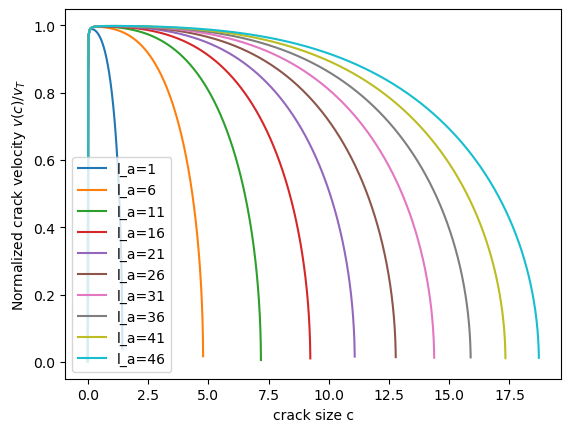

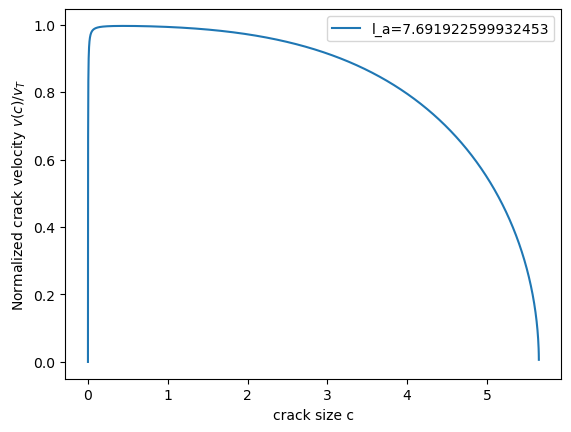

In [30]:
c0 = 1e-3 # taille du défaut initial [m]

# Rq : si c0=1mm, c'est l'odg pour les brine pockets. Si les défauts initiaux sont de l'ordre de 10cm, c'est plutôt des défauts liés aux coins de la plaque 
# et aux hétérogénéités d'épaisseur etc.


# parametres glace
#E=2e9 # (Saguenay 2024)
#h = 12e-2 # (Saguenay 2024)
E=3e9 # (Bicwin 2026)
h = 50e-2 # (BicWin 2026)

cvals = np.linspace(c0, 100e3*c0, 100000)

plt.figure()
for l_a in range(1,50,5):
    #l_a = 10
    A = l_a * h
    alpha = (2*np.pi * c0**2)/A
    plt.plot(cvals, geometric_function_dynfrac(cvals, alpha, c0=c0), label='l_a='+str(l_a))
plt.xlabel('crack size c')
plt.ylabel('Normalized crack velocity $v(c)/v_T$')
plt.legend()
plt.show()


# et pour la valeur de l_d qui nous intéresse :
nu = 0.3
D = (E*(h**3))/(12*(1-nu**2))
l_d = (D/(1e3*9.81))**(1/4)
l_a = l_d
plt.figure()
A = l_a * h
alpha = (2*np.pi * c0**2)/A
plt.plot(cvals, geometric_function_dynfrac(cvals, alpha, c0=c0), label='l_a='+str(l_a))
plt.xlabel('crack size c')
plt.ylabel('Normalized crack velocity $v(c)/v_T$')
plt.legend()
plt.show()


In [18]:
D = 2e9*(0.12**3)/10
(D/(1e3*9.81))**(1/4)

2.436274287093712

## Enoncé du modèle pour le cas de la banquise

Dans le cas de la banquise, l'idée est que, lorsque la vitesse de propagation du crack dans la direction "principale" s'annule, les défaut que le crack rencontre affectent plus sa propagation que lorsqu'il va vite.
Maintenant, comme dans le modèle simplifié ci-dessus, on a besoin de quelques paramètres d'entrée :

- $c_0$
- $l_A$
- $E$

Et bien sûr, étant donné que dans notre cas on considère la flexion :

- $h$

Ce qui donne : $A = l_A \cdot h$

Et par conséquent, l'unique paramètre entrant en jeu dans la sélection de la distance d'arrêt du crack est le paramètre $\alpha$ :

$\alpha = \frac{2\pi c_0^2}{A}$

Une première intuition est que la longueur $l_A$ pourrait être choisie comme étant la longueur de flexion $l_D$. Pourquoi ?

Imaginons une longue et large plaque de glace qui flotte à la surface de l'eau. A moins d'avoir un champ de vagues et une épaisseur parfaitement constante, il est compliqué de la déformer uniquement selon une direction (par exemple avec un champ d'ondes planes). La raison est la suivante : la plaque est "trop" flexible. Si la longueur de flexion $l_D$ était faible devant la largeur de la plaque, ce ne serait pas trop compliqué de la faire fléchir selon une seule direction. Dans le cas où la plaque est "trop" flexible, cela signifie que $l_D$ est petit comparé à la largeur de la plaque. On en conclut que $l_D$ contraint le problème, et que donc on peut raisonnablement supposer que cette longeur caractéristique soit identifiée à la longueur $l_A$ dans le modèle (plus simple) extrait du livre de Lawn (1975).